In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import random
import pickle
import matplotlib.pyplot as plt
import math
import os

PICKLE_FILE = "splined_trajectories_3.txt"
MODEL_OUT = "mlp_trajectory_model.pt"


# CONFIG
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8              # number of trajectories per batch
LR = 1e-3
EPOCHS = 150
H1 = 128
H2 = 64
TEACHER_FORCING_START = 1.0  # initial prob of using ground-truth prev
TEACHER_FORCING_END = 0.0    # end prob
SCHEDULE_EPOCHS = EPOCHS     # linear schedule length
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -------------------------
# 1) Load pickled trajectories
# -------------------------
with open(PICKLE_FILE, "rb") as f:
    output = pickle.load(f)

# output expected: list of arrays each shape (T,4) -> [left_x,left_y,right_x,right_y]
print(f"Loaded {len(output)} trajectories")

# drop empty trajectories if any
output = [np.array(t) for t in output if (t is not None and len(t) > 0)]

# Assume 'output' exists: list of (T,4) arrays
# And helper that returns mover & target for a trajectory
def moving_arm_and_target(traj):
    left = traj[:, :2]; right = traj[:, 2:]
    left_range = np.max(np.linalg.norm(left - left[0], axis=1))
    right_range = np.max(np.linalg.norm(right - right[0], axis=1))
    if left_range > right_range:
        return 'L', left[-1]
    else:
        return 'R', right[-1]

# Dataset returning whole trajectories and their target
class TrajSeqDataset(Dataset):
    def __init__(self, traj_list):
        self.traj_list = [np.array(t, dtype=np.float32) for t in traj_list]
    def __len__(self):
        return len(self.traj_list)
    def __getitem__(self, idx):
        traj = self.traj_list[idx]   # shape (T,4)
        mover, target = moving_arm_and_target(traj)
        target = np.array(target, dtype=np.float32)
        return traj, target, mover

# Create train/val split by trajectories
num_traj = len(output)
indices = np.arange(num_traj)
np.random.shuffle(indices)
val_frac = 0.2
val_count = int(val_frac * num_traj)
val_idx = indices[:val_count]
train_idx = indices[val_count:]

train_trajs = [output[i] for i in train_idx]
val_trajs = [output[i] for i in val_idx]

train_ds = TrajSeqDataset(train_trajs)
val_ds = TrajSeqDataset(val_trajs)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: x)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: x)

# Simple MLP model (same as before)
class MLP(nn.Module):
    def __init__(self, inp_dim=6, h1=H1, h2=H2, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_dim)
        )
    def forward(self, x):
        return self.net(x)

model = MLP().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# Linear schedule for teacher forcing probability
def teacher_forcing_prob(epoch):
    frac = min(1.0, epoch / float(max(1, SCHEDULE_EPOCHS)))
    return TEACHER_FORCING_START + (TEACHER_FORCING_END - TEACHER_FORCING_START) * frac

train_losses = []
val_losses = []

# Training loop (unroll trajectories; batch is list of trajs)
for epoch in range(1, EPOCHS+1):
    model.train()
    tf_p = teacher_forcing_prob(epoch)  # prob to use ground-truth prev
    train_loss_epoch = 0.0
    n_samples = 0

    for batch in train_loader:
        # batch is list of items [(traj, target, mover), ...] with length BATCH_SIZE (may be smaller last)
        opt.zero_grad()
        batch_loss = 0.0
        batch_count = 0

        for traj, target, mover in batch:
            traj = np.array(traj, dtype=np.float32)
            T = traj.shape[0]
            target_vec = np.array(target, dtype=np.float32)  # (2,)
            # autoregressive roll-out for this trajectory
            prev = traj[0].copy()   # start from true initial position (or home)
            loss_traj = 0.0
            for t in range(1, T):
                # construct input: [target_x, target_y, prev(4)]
                inp = np.concatenate([target_vec, prev]).astype(np.float32)
                inp_t = torch.from_numpy(inp).float().to(DEVICE).unsqueeze(0)  # (1,6)
                pred = model(inp_t)   # (1,4)
                # compute loss vs ground-truth traj[t]
                gt = torch.from_numpy(traj[t].astype(np.float32)).float().to(DEVICE).unsqueeze(0)
                loss_step = loss_fn(pred, gt)
                loss_traj += loss_step
                # decide next prev: with prob tf_p use gt, else use pred (scheduled sampling)
                if random.random() < tf_p:
                    prev = traj[t].copy()   # teacher forcing
                else:
                    prev = pred.detach().cpu().numpy().reshape(4,)  # model output as next input
            # accumulate loss for this trajectory
            batch_loss += loss_traj
            batch_count += 1
            n_samples += T-1

        # average batch loss over trajectories in batch
        if batch_count > 0:
            batch_loss = batch_loss / batch_count
            batch_loss.backward()
            opt.step()
            train_loss_epoch += batch_loss.item() * batch_count

    train_loss_epoch = train_loss_epoch / len(train_ds)

    # validation (use pure teacher forcing or pure autoregressive to test — choose teacher forcing here)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            for traj, target, mover in batch:
                traj = np.array(traj, dtype=np.float32)
                T = traj.shape[0]
                target_vec = np.array(target, dtype=np.float32)
                prev = traj[0].copy()
                loss_traj = 0.0
                for t in range(1, T):
                    inp = np.concatenate([target_vec, prev]).astype(np.float32)
                    inp_t = torch.from_numpy(inp).float().to(DEVICE).unsqueeze(0)
                    pred = model(inp_t)
                    gt = torch.from_numpy(traj[t].astype(np.float32)).float().to(DEVICE).unsqueeze(0)
                    loss_traj += loss_fn(pred, gt)
                    # here for validation we can either use teacher forcing or model outputs; using teacher forcing gives one-step error
                    prev = pred.detach().cpu().numpy().reshape(4,) #pure autoregressive prediction
                val_loss += loss_traj.item()

    val_loss = val_loss / len(val_ds)
    
    train_losses.append(train_loss_epoch)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch} | train_loss {train_loss_epoch:.6f} | val_loss {val_loss:.6f} | tf_p {tf_p:.3f}")

print("Training complete")


Loaded 2102 trajectories
Epoch 1 | train_loss 0.088304 | val_loss 0.035241 | tf_p 0.993
Epoch 10 | train_loss 0.000221 | val_loss 0.014472 | tf_p 0.933
Epoch 20 | train_loss 0.000168 | val_loss 0.288122 | tf_p 0.867
Epoch 30 | train_loss 0.000172 | val_loss 0.043700 | tf_p 0.800
Epoch 40 | train_loss 0.000151 | val_loss 0.027553 | tf_p 0.733
Epoch 50 | train_loss 0.000081 | val_loss 0.011103 | tf_p 0.667
Epoch 60 | train_loss 0.000333 | val_loss 0.155808 | tf_p 0.600
Epoch 70 | train_loss 0.000180 | val_loss 0.005531 | tf_p 0.533
Epoch 80 | train_loss 0.000396 | val_loss 0.001837 | tf_p 0.467
Epoch 90 | train_loss 0.000395 | val_loss 0.004836 | tf_p 0.400
Epoch 100 | train_loss 0.000533 | val_loss 0.001716 | tf_p 0.333
Epoch 110 | train_loss 0.001877 | val_loss 0.013261 | tf_p 0.267
Epoch 120 | train_loss 0.002252 | val_loss 0.009343 | tf_p 0.200
Epoch 130 | train_loss 0.003620 | val_loss 0.003331 | tf_p 0.133
Epoch 140 | train_loss 0.004698 | val_loss 0.006485 | tf_p 0.067
Epoch 150 |

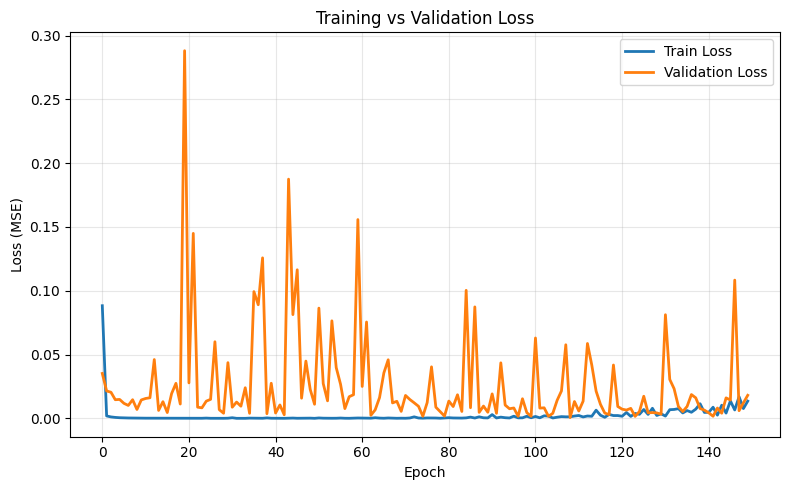

In [2]:

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()